<div style="width: 76ch;">
<h3>Ruitenwissermechanisme</h3>
(<em>Colin Cools, Lander Cortens</em>)

<div style="height: 20rem;">
 <img style="border: 0; display: inline-block;" height="100%"
      src="images/ruitenwissers_foto.png"
 >
</div>

</div>

In [1]:


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

%matplotlib widget


In [2]:
# Vaste punten in wereldframe
grond_A = np.array([0.00, 0.00])
grond_D = np.array([0.76, 0.66])
grond_I = np.array([1.77, 0.66])
grond_H = np.array([1.79, 0.01])

# kinematic parameters, in SI units:
r1 = 0.10  #m
r2 = 0.99  #m
r4 = 1.01  #m 
r6 = 0.90  #m
r7 = 0.50  #m

# Stang 3 — body-frame coordinaten van joints t.o.v. D
L_DK = 1.12 #m 
L_DE = 0.29 #m 
L_DC = 0.16 #m
L_DF = 0.41 #m 

# Stang 5 — body-frame coordinaten t.o.v. i
L_iL = 1.13 #m
L_iJ = 0.28 #m

# Afgeleide grondvectoren
rAD = grond_D - grond_A
rDI = grond_I - grond_D
rDH = grond_H - grond_D

In [3]:
# configuration of numerical simulation interval and sampling:
omega   = 1.5    # rad/s -- frequentie van de oscillatie
t_begin = 0.0
t_end   = 2*np.pi/omega    # 1 oscillatie-cyclus
Ts      = 0.1
t = np.arange(t_begin, t_end + Ts, Ts)

'''
# angular position driver:
theta1_mid = np.deg2rad(78.5)
A        = np.deg2rad(14.0)
theta1   = theta1_mid + A * np.sin(omega * t)
dtheta1  =  omega * A * np.cos(omega * t)
ddtheta1 = -omega ** 2 * A * np.sin(omega * t)
'''

# driver: stang 1 (roterend)
theta1_0 = np.deg2rad(65)
theta1   = theta1_0 + omega * t
dtheta1  = omega * np.ones_like(t)
ddtheta1 = np.zeros_like(t)

# initial conditions for nonlinear solver ("fsolve") of position closure:f.
theta2_init = np.deg2rad( 15)
theta3_init = np.deg2rad(115)
theta4_init = np.deg2rad(-20)   # stang 6
theta5_init = np.deg2rad(50)   # stang 7
theta6_init = np.deg2rad(  0)   # stang 4
theta7_init = np.deg2rad(120)   # stang 5

In [4]:
# Function to rotate a vector z over an angle theta:
def rotate_vector(z, theta):
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta), np.cos(theta)]])
    return np.dot(rotation_matrix, z)

In [5]:
# Define function to compute "gap" in position closure:
def loop_closure_eqs(theta_init, theta1,
                     r1, r2, r4, r6, r7,
                     L_DC, L_DE, L_DF, L_iJ,
                     rAD, rDI, rDH):
    th2, th3, th4, th5, th6, th7 = theta_init

    # Lus 1: A-B-C-D
    F1 = r1*np.cos(theta1) + r2*np.cos(th2) + L_DC*np.cos(th3) - rAD[0]
    F2 = r1*np.sin(theta1) + r2*np.sin(th2) + L_DC*np.sin(th3) - rAD[1]

    # Lus 2: D-E-J-i
    F3 = L_DE*np.cos(th3) + r4*np.cos(th6) - L_iJ*np.cos(th7) - rDI[0]
    F4 = L_DE*np.sin(th3) + r4*np.sin(th6) - L_iJ*np.sin(th7) - rDI[1]

    # Lus 3: D-F-G-H
    F5 = -L_DF*np.cos(th3) + r6*np.cos(th4) - r7*np.cos(th5) - rDH[0]
    F6 = -L_DF*np.sin(th3) + r6*np.sin(th4) - r7*np.sin(th5) - rDH[1]

    return [F1, F2, F3, F4, F5, F6]

In [6]:
# Function to compute the kinematics of four-bar mechanism:

def kinematics(r1, r2, r4, r6, r7, L_DC, L_DE, L_DF, L_iJ,
               rAD, rDI, rDH,
               theta1, dtheta1, ddtheta1,
               theta2_init, theta3_init, theta4_init,
               theta5_init, theta6_init, theta7_init, t):
    optim_options = {"full_output":True}  # options for fsolve

    # numerically solving the position closure at all sampling times:
    for k, time in enumerate(t):
        # Position Analysis
        x0 = [theta2_init, theta3_init, theta4_init,
              theta5_init, theta6_init, theta7_init]
        x, _, ier, msg = fsolve(
            lambda x: loop_closure_eqs(x, theta1[k],
                                       r1, r2, r4, r6, r7,
                                       L_DC, L_DE, L_DF, L_iJ,
                                       rAD, rDI, rDH),
            x0, **optim_options)
        if ier != 1:
            print(f'fsolve k={k} ier={ier}: {msg}')
        theta2[k], theta3[k], theta4[k], theta5[k], theta6[k], theta7[k] = x

        t2,t3,t4,t5,t6,t7 = x

        # velocity closure:
        A = np.array([
          [-r2*np.sin(t2), -L_DC*np.sin(t3), 0,             0,             0,            0           ],
          [ r2*np.cos(t2),  L_DC*np.cos(t3), 0,             0,             0,            0           ],
          [ 0,             -L_DE*np.sin(t3), 0,             0,            -r4*np.sin(t6), L_iJ*np.sin(t7)],
          [ 0,              L_DE*np.cos(t3), 0,             0,             r4*np.cos(t6),-L_iJ*np.cos(t7)],
          [ 0,              L_DF*np.sin(t3),-r6*np.sin(t4), r7*np.sin(t5), 0,            0           ],
          [ 0,             -L_DF*np.cos(t3), r6*np.cos(t4),-r7*np.cos(t5), 0,            0           ],
        ])
        B = np.array([ r1*np.sin(theta1[k])*dtheta1[k],
                      -r1*np.cos(theta1[k])*dtheta1[k],
                       0, 0, 0, 0])
        
        x = np.linalg.solve(A, B)
        dtheta2[k], dtheta3[k], dtheta4[k], dtheta5[k], dtheta6[k], dtheta7[k] = x
        cond[k] = np.linalg.cond(A)

        # acceleration closure:
        dt2,dt3,dt4,dt5,dt6,dt7 = x
        B = np.array([
            # rij 1 (F1):
            r1*np.cos(theta1[k])*dtheta1[k]**2 + r1*np.sin(theta1[k])*ddtheta1[k]
            + r2*np.cos(t2)*dt2**2 + L_DC*np.cos(t3)*dt3**2,
            # rij 2 (F2):
            r1*np.sin(theta1[k])*dtheta1[k]**2 - r1*np.cos(theta1[k])*ddtheta1[k]
            + r2*np.sin(t2)*dt2**2 + L_DC*np.sin(t3)*dt3**2,
            # rij 3 (F3):
            L_DE*np.cos(t3)*dt3**2 + r4*np.cos(t6)*dt6**2 - L_iJ*np.cos(t7)*dt7**2,
            # rij 4 (F4):
            L_DE*np.sin(t3)*dt3**2 + r4*np.sin(t6)*dt6**2 - L_iJ*np.sin(t7)*dt7**2,
            # rij 5 (F5):
           -L_DF*np.cos(t3)*dt3**2 + r6*np.cos(t4)*dt4**2 - r7*np.cos(t5)*dt5**2,
            # rij 6 (F6):
           -L_DF*np.sin(t3)*dt3**2 + r6*np.sin(t4)*dt4**2 - r7*np.sin(t5)*dt5**2,
        ])

        # Note: A matrix is the same as for velocities.
        x = np.linalg.solve(A, B)
        ddtheta2[k],ddtheta3[k],ddtheta4[k],ddtheta5[k],ddtheta6[k],ddtheta7[k] = x

        # Next iteration with initial values from by simple integration:
        dt = (t[1]-t[0])
        theta2_init = t2 + dt*dt2
        theta3_init = t3 + dt*dt3
        theta4_init = t4 + dt*dt4
        theta5_init = t5 + dt*dt5
        theta6_init = t6 + dt*dt6
        theta7_init = t7 + dt*dt7

    return (theta2, theta3, theta4, theta5, theta6, theta7,
            dtheta2,dtheta3,dtheta4,dtheta5,dtheta6,dtheta7,
            ddtheta2,ddtheta3,ddtheta4,ddtheta5,ddtheta6,ddtheta7,
            cond)


In [7]:
# compute the kinematics at all sample times "t":

t_size = len(t)              # number of iterations
sim_fraction = 2             # fraction of simulated frames in animation
frames = t_size/sim_fraction # number of animated iterations
delta = int(np.floor(t_size/frames))    # time between frames
index_vec = np.arange(0, t_size, delta) # index of animated frames        

theta2   = np.zeros_like(t)
theta3   = np.zeros_like(t)
theta4   = np.zeros_like(t)
theta5   = np.zeros_like(t)
theta6   = np.zeros_like(t)
theta7   = np.zeros_like(t)
dtheta2  = np.zeros_like(t)
dtheta3  = np.zeros_like(t)
dtheta4  = np.zeros_like(t)
dtheta5  = np.zeros_like(t)
dtheta6  = np.zeros_like(t)
dtheta7  = np.zeros_like(t)
ddtheta2 = np.zeros_like(t)
ddtheta3 = np.zeros_like(t)
ddtheta4 = np.zeros_like(t)
ddtheta5 = np.zeros_like(t)
ddtheta6 = np.zeros_like(t)
ddtheta7 = np.zeros_like(t)

cond   = np.zeros_like(t) # condition number of matrix A

(theta2, theta3, theta4, theta5, theta6, theta7,
 dtheta2,dtheta3,dtheta4,dtheta5,dtheta6,dtheta7,
 ddtheta2,ddtheta3,ddtheta4,ddtheta5,ddtheta6,ddtheta7,
 cond) = kinematics(
    r1, r2, r4, r6, r7, L_DC, L_DE, L_DF, L_iJ,
    rAD, rDI, rDH,
    theta1, dtheta1, ddtheta1,
    theta2_init, theta3_init, theta4_init,
    theta5_init, theta6_init, theta7_init, t)


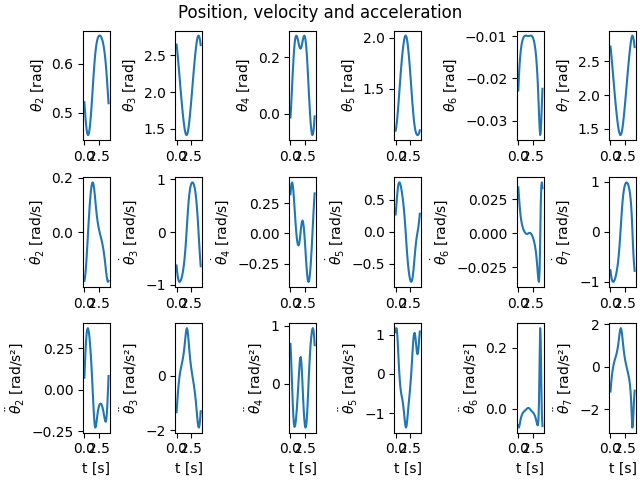

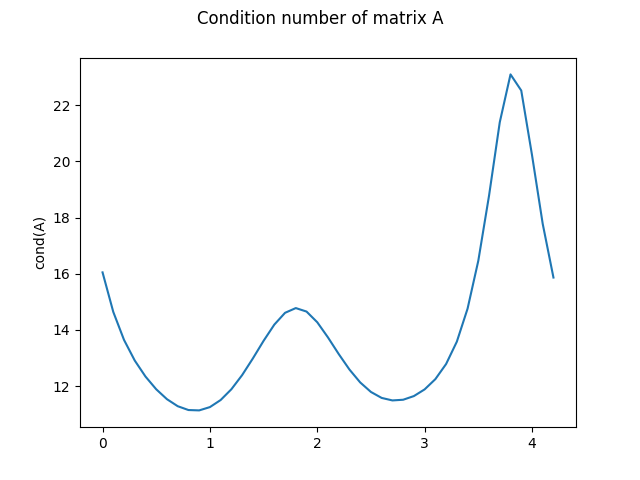

In [8]:
# plot position, velocity and acceleration profiles:

fig1, ax1 = plt.subplots(nrows=3,ncols=6,constrained_layout=True)
fig1.suptitle("Position, velocity and acceleration")

labels_pos = [r'$\theta_2$ [rad]', r'$\theta_3$ [rad]', r'$\theta_4$ [rad]', r'$\theta_5$ [rad]', r'$\theta_6$ [rad]', r'$\theta_7$ [rad]']
labels_vel = [r'$\dot{\theta}_2$ [rad/s]', r'$\dot{\theta}_3$ [rad/s]', r'$\dot{\theta}_4$ [rad/s]', r'$\dot{\theta}_5$ [rad/s]', r'$\dot{\theta}_6$ [rad/s]', r'$\dot{\theta}_7$ [rad/s]']
labels_acc = [r'$\ddot{\theta}_2$ [rad/s²]', r'$\ddot{\theta}_3$ [rad/s²]', r'$\ddot{\theta}_4$ [rad/s²]', r'$\ddot{\theta}_5$ [rad/s²]', r'$\ddot{\theta}_6$ [rad/s²]', r'$\ddot{\theta}_7$ [rad/s²]']
pos   = [theta2, theta3, theta4, theta5, theta6, theta7]
vel   = [dtheta2,dtheta3,dtheta4,dtheta5,dtheta6,dtheta7]
acc   = [ddtheta2,ddtheta3,ddtheta4,ddtheta5,ddtheta6,ddtheta7]

for i in range(6):
    ax1[0,i].plot(t, pos[i]);  ax1[0,i].set_ylabel(labels_pos[i])
    ax1[1,i].plot(t, vel[i]);  ax1[1,i].set_ylabel(labels_vel[i])
    ax1[2,i].plot(t, acc[i]);  ax1[2,i].set_ylabel(labels_acc[i])
    ax1[2,i].set_xlabel('t [s]')

plt.show()

# plot of condition number:
figc, axc = plt.subplots()
figc.suptitle("Condition number of matrix A")

axc.plot(t, cond)
axc.set_ylabel("cond(A)")
plt.show()


In [9]:
# Animation of mechanism motion
plt.ioff()               # don't show figure until drawn explicitly:
fig2, ax = plt.subplots() # Initialize the figure

# simple drawing window, like the vierstangen notebook:
x_left, x_right = -0.4, 3.0
y_bottom, y_top = -0.4, 1.8

def update(frame):
    global fig2, ax, x_left, x_right, y_bottom, y_top, index_vec
    ax.cla()         # Clear the current axes
    ax.axis('equal') # Ensures 1 unit on x == 1 unit on y
    ax.set_xlabel('[m]')
    ax.set_ylabel('[m]')
    ax.set_xlim([x_left, x_right])
    ax.set_ylim([y_bottom, y_top])
    k = index_vec[frame]
    time_now = t[k]
    ax.set_title(f'Time {time_now: .2f}')
    #ax.set_title(f'Frame {frame}')

    # joint posities
    B = grond_A + rotate_vector(np.array([r1,0]), theta1[k])
    C = B       + rotate_vector(np.array([r2,0]), theta2[k])
    K = grond_D + rotate_vector(np.array([L_DK,0]), theta3[k])
    E = grond_D + rotate_vector(np.array([L_DE,0]), theta3[k])
    F = grond_D + rotate_vector(np.array([-L_DF,0]), theta3[k])
    L = grond_I + rotate_vector(np.array([L_iL,0]), theta7[k])
    J = grond_I + rotate_vector(np.array([L_iJ,0]), theta7[k])
    G = grond_H + rotate_vector(np.array([r7,0]),  theta5[k])

    # Teken stangen (kleur per stang)
    ax.plot([grond_A[0],B[0]],[grond_A[1],B[1]],'b-',lw=3)             # 1
    ax.plot([B[0],C[0]],[B[1],C[1]],'g-',lw=3)                          # 2
    ax.plot([K[0],F[0]],[K[1],F[1]],'r-',lw=3)                          # 3 (lichaam)
    ax.plot([E[0],J[0]],[E[1],J[1]],'m-',lw=3)                          # 4
    ax.plot([L[0],grond_I[0]],[L[1],grond_I[1]],'c-',lw=3)              # 5
    ax.plot([F[0],G[0]],[F[1],G[1]],color='orange',lw=3)                # 6
    ax.plot([G[0],grond_H[0]],[G[1],grond_H[1]],color='brown',lw=3)     # 7

    # gewrichten
    for p,n in [(B,'B'),(C,'C'),(E,'E'),(F,'F'),(G,'G'),(J,'J'),(K,'K'),(L,'L')]:
        ax.plot(*p,'ko',ms=5)
    # vaste punten in rood
    for p,n in [(grond_A,'A'),(grond_D,'D'),(grond_I,'i'),(grond_H,'H')]:
        ax.plot(*p,'o',color='red',ms=12)
        ax.annotate(n,p,xytext=(7,7),textcoords='offset points',fontweight='bold')
    return ax,

# animate the mechanism:
ani = FuncAnimation(fig2, update, frames=len(index_vec), interval=50, repeat=False)



In [10]:
# display mechanism animation:
ani_html = ani.to_jshtml(default_mode='once')
HTML(ani_html)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


...

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


In [11]:
# dynamic parameters, defined in a local frame on each of the bars:
# (COG = centre of gravity; stangen gemodelleerd als dunne staven, massa ~ lengte)

rho_lin = 15.4   # kg/m  (massa per lengte-eenheid, idem voorbeeld 4-bar: ronde stalen staaf)

# totale (fysieke) lengte van elke stang:
L1 = r1                 # stang 1: A - B
L2 = r2                 # stang 2: B - C
L3 = L_DK + L_DF        # stang 3: K - F (via D)
L4 = r4                 # stang 4: E - J
L5 = L_iL               # stang 5: i - L
L6 = r6                 # stang 6: F - G
L7 = r7                 # stang 7: H - G

# mass of each bar:
m1 = rho_lin * L1
m2 = rho_lin * L2
m3 = rho_lin * L3
m4 = rho_lin * L4
m5 = rho_lin * L5
m6 = rho_lin * L6
m7 = rho_lin * L7

# X- en Y-coordinaten van de COG in het body-frame van elke stang.
# De oorsprong van elk body-frame is dezelfde "eerste" joint als in de kinematica,
# de body-x-as wijst volgens de bijhorende hoek.
X1, Y1 = r1 / 2, 0                 # stang 1: oorsprong A,  COG op midden A-B
X2, Y2 = r2 / 2, 0                 # stang 2: oorsprong B,  COG op midden B-C
X3, Y3 = (L_DK - L_DF) / 2, 0      # stang 3: oorsprong D,  COG op midden F-K
X4, Y4 = r4 / 2, 0                 # stang 4: oorsprong E,  COG op midden E-J
X5, Y5 = L_iL / 2, 0               # stang 5: oorsprong i,  COG op midden i-L
X6, Y6 = r6 / 2, 0                 # stang 6: oorsprong F,  COG op midden F-G
X7, Y7 = r7 / 2, 0                 # stang 7: oorsprong H,  COG op midden H-G

# moments of inertia at center of mass (formula of a thin rod  m*L^2/12):
J1 = m1 * L1 ** 2 / 12
J2 = m2 * L2 ** 2 / 12
J3 = m3 * L3 ** 2 / 12
J4 = m4 * L4 ** 2 / 12
J5 = m5 * L5 ** 2 / 12
J6 = m6 * L6 ** 2 / 12
J7 = m7 * L7 ** 2 / 12


In [12]:
# formulas for inverse dynamics:
def dynamics_ruitenwisser(theta1, theta2, theta3, theta4, theta5, theta6, theta7,
                          dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
                          ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7,
                          r1, r2, r4, r6, r7, L_DE, L_DF, L_iJ,
                          X1, X2, X3, X4, X5, X6, X7,
                          Y1, Y2, Y3, Y4, Y5, Y6, Y7,
                          m1, m2, m3, m4, m5, m6, m7,
                          J1, J2, J3, J4, J5, J6, J7,
                          grond_A, grond_D, grond_H, grond_I, t):

    # COG-versnelling van een staaf via een referentiepunt (pivot) op de staaf:
    #   a_cog = a_pivot + alpha x r  -  omega**2 * r          (2D, met scalair omega/alpha)
    def cog_acc(a_base, omega, alpha, r_local, theta):
        r = rotate_vector(r_local, theta)            # body -> wereld
        return a_base + alpha * np.array([-r[1], r[0]]) - omega ** 2 * r

    # kruisproduct in 2D:   r x F = r_x * F_y - r_y * F_x
    def cross2(r, F):
        return r[0] * F[1] - r[1] * F[0]

    for k in range(len(t)):
        # joint-posities in het wereldframe:
        A = grond_A
        B = grond_A + rotate_vector(np.array([r1, 0]),    theta1[k])
        C = B       + rotate_vector(np.array([r2, 0]),    theta2[k])
        D = grond_D
        E = grond_D + rotate_vector(np.array([ L_DE, 0]), theta3[k])
        F = grond_D + rotate_vector(np.array([-L_DF, 0]), theta3[k])
        G = grond_H + rotate_vector(np.array([r7, 0]),    theta5[k])
        H = grond_H
        I = grond_I
        J = grond_I + rotate_vector(np.array([L_iJ, 0]),  theta7[k])

        # COG-posities in het wereldframe:
        cog1 = grond_A + rotate_vector(np.array([X1, Y1]), theta1[k])
        cog2 = B       + rotate_vector(np.array([X2, Y2]), theta2[k])
        cog3 = grond_D + rotate_vector(np.array([X3, Y3]), theta3[k])
        cog4 = E       + rotate_vector(np.array([X4, Y4]), theta6[k])   # stang 4 -> hoek theta6
        cog5 = grond_I + rotate_vector(np.array([X5, Y5]), theta7[k])   # stang 5 -> hoek theta7
        cog6 = F       + rotate_vector(np.array([X6, Y6]), theta4[k])   # stang 6 -> hoek theta4
        cog7 = grond_H + rotate_vector(np.array([X7, Y7]), theta5[k])   # stang 7 -> hoek theta5

        # COG-versnellingen:
        # gegronde stangen (1,3,5,7) draaien om een vast punt -> a_base = 0
        a1 = cog_acc(0, dtheta1[k], ddtheta1[k], np.array([X1, Y1]), theta1[k])
        a3 = cog_acc(0, dtheta3[k], ddtheta3[k], np.array([X3, Y3]), theta3[k])
        a5 = cog_acc(0, dtheta7[k], ddtheta7[k], np.array([X5, Y5]), theta7[k])
        a7 = cog_acc(0, dtheta5[k], ddtheta5[k], np.array([X7, Y7]), theta5[k])
        # stang 2: basispunt B beweegt mee op stang 1
        aB = cog_acc(0, dtheta1[k], ddtheta1[k], np.array([r1, 0]), theta1[k])
        a2 = cog_acc(aB, dtheta2[k], ddtheta2[k], np.array([X2, Y2]), theta2[k])
        # stang 4: basispunt E beweegt mee op stang 3
        aE = cog_acc(0, dtheta3[k], ddtheta3[k], np.array([L_DE, 0]), theta3[k])
        a4 = cog_acc(aE, dtheta6[k], ddtheta6[k], np.array([X4, Y4]), theta6[k])
        # stang 6: basispunt F beweegt mee op stang 3
        aF = cog_acc(0, dtheta3[k], ddtheta3[k], np.array([-L_DF, 0]), theta3[k])
        a6 = cog_acc(aF, dtheta4[k], ddtheta4[k], np.array([X6, Y6]), theta4[k])

        # Onbekenden-vector x (21 stuks):
        #   0,1 : F_A    2,3 : F_B    4,5 : F_C    6,7 : F_D    8,9 : F_E
        #  10,11: F_F   12,13: F_G   14,15: F_H   16,17: F_I   18,19: F_J    20: M_A
        # Per bewegende stang: Newton (x, y) + Euler om COG = 3 vergelijkingen,
        # 7 stangen x 3 = 21 vergelijkingen.  Stelsel:  A x = B.
        A_mat = np.zeros((21, 21))
        B_vec = np.zeros(21)

        # ----- stang 1 : +F_A (grond), -F_B (reactie van stang 2), aandrijfkoppel M_A -----
        A_mat[0, 0] = 1; A_mat[0, 2] = -1;                 B_vec[0] = m1 * a1[0]
        A_mat[1, 1] = 1; A_mat[1, 3] = -1;                 B_vec[1] = m1 * a1[1]
        rA = A - cog1; rB = B - cog1
        A_mat[2, 0] = -rA[1]; A_mat[2, 1] =  rA[0]         # +F_A
        A_mat[2, 2] =  rB[1]; A_mat[2, 3] = -rB[0]         # -F_B
        A_mat[2, 20] = 1                                   # M_A
        B_vec[2] = J1 * ddtheta1[k]

        # ----- stang 2 : +F_B, -F_C -----
        A_mat[3, 2] = 1; A_mat[3, 4] = -1;                 B_vec[3] = m2 * a2[0]
        A_mat[4, 3] = 1; A_mat[4, 5] = -1;                 B_vec[4] = m2 * a2[1]
        rB = B - cog2; rC = C - cog2
        A_mat[5, 2] = -rB[1]; A_mat[5, 3] =  rB[0]
        A_mat[5, 4] =  rC[1]; A_mat[5, 5] = -rC[0]
        B_vec[5] = J2 * ddtheta2[k]

        # ----- stang 3 : +F_C, +F_D (grond), -F_E, -F_F -----
        A_mat[6, 4] = 1; A_mat[6, 6] = 1; A_mat[6, 8] = -1; A_mat[6, 10] = -1;  B_vec[6] = m3 * a3[0]
        A_mat[7, 5] = 1; A_mat[7, 7] = 1; A_mat[7, 9] = -1; A_mat[7, 11] = -1;  B_vec[7] = m3 * a3[1]
        rC = C - cog3; rD = D - cog3; rE = E - cog3; rF = F - cog3
        A_mat[8, 4]  = -rC[1]; A_mat[8, 5]  =  rC[0]       # +F_C
        A_mat[8, 6]  = -rD[1]; A_mat[8, 7]  =  rD[0]       # +F_D
        A_mat[8, 8]  =  rE[1]; A_mat[8, 9]  = -rE[0]       # -F_E
        A_mat[8, 10] =  rF[1]; A_mat[8, 11] = -rF[0]       # -F_F
        B_vec[8] = J3 * ddtheta3[k]

        # ----- stang 4 : +F_E, -F_J -----
        A_mat[9, 8]  = 1; A_mat[9, 18]  = -1;              B_vec[9]  = m4 * a4[0]
        A_mat[10, 9] = 1; A_mat[10, 19] = -1;              B_vec[10] = m4 * a4[1]
        rE = E - cog4; rJ = J - cog4
        A_mat[11, 8]  = -rE[1]; A_mat[11, 9]  =  rE[0]
        A_mat[11, 18] =  rJ[1]; A_mat[11, 19] = -rJ[0]
        B_vec[11] = J4 * ddtheta6[k]

        # ----- stang 5 : +F_I (grond), +F_J -----
        A_mat[12, 16] = 1; A_mat[12, 18] = 1;              B_vec[12] = m5 * a5[0]
        A_mat[13, 17] = 1; A_mat[13, 19] = 1;              B_vec[13] = m5 * a5[1]
        rI = I - cog5; rJ = J - cog5
        A_mat[14, 16] = -rI[1]; A_mat[14, 17] = rI[0]
        A_mat[14, 18] = -rJ[1]; A_mat[14, 19] = rJ[0]
        B_vec[14] = J5 * ddtheta7[k]

        # ----- stang 6 : +F_F, -F_G -----
        A_mat[15, 10] = 1; A_mat[15, 12] = -1;             B_vec[15] = m6 * a6[0]
        A_mat[16, 11] = 1; A_mat[16, 13] = -1;             B_vec[16] = m6 * a6[1]
        rF = F - cog6; rG = G - cog6
        A_mat[17, 10] = -rF[1]; A_mat[17, 11] =  rF[0]
        A_mat[17, 12] =  rG[1]; A_mat[17, 13] = -rG[0]
        B_vec[17] = J6 * ddtheta4[k]

        # ----- stang 7 : +F_G, +F_H (grond) -----
        A_mat[18, 12] = 1; A_mat[18, 14] = 1;              B_vec[18] = m7 * a7[0]
        A_mat[19, 13] = 1; A_mat[19, 15] = 1;              B_vec[19] = m7 * a7[1]
        rG = G - cog7; rH = H - cog7
        A_mat[20, 12] = -rG[1]; A_mat[20, 13] = rG[0]
        A_mat[20, 14] = -rH[1]; A_mat[20, 15] = rH[0]
        B_vec[20] = J7 * ddtheta5[k]

        x = np.linalg.lstsq(A_mat, B_vec, rcond=None)[0]

        # Save results
        F_A_x[k] = x[0];  F_A_y[k] = x[1]
        F_B_x[k] = x[2];  F_B_y[k] = x[3]
        F_C_x[k] = x[4];  F_C_y[k] = x[5]
        F_D_x[k] = x[6];  F_D_y[k] = x[7]
        F_E_x[k] = x[8];  F_E_y[k] = x[9]
        F_F_x[k] = x[10]; F_F_y[k] = x[11]
        F_G_x[k] = x[12]; F_G_y[k] = x[13]
        F_H_x[k] = x[14]; F_H_y[k] = x[15]
        F_I_x[k] = x[16]; F_I_y[k] = x[17]
        F_J_x[k] = x[18]; F_J_y[k] = x[19]
        M_A[k]   = x[20]

    return (F_A_x, F_A_y, F_B_x, F_B_y, F_C_x, F_C_y, F_D_x, F_D_y, F_E_x, F_E_y,
            F_F_x, F_F_y, F_G_x, F_G_y, F_H_x, F_H_y, F_I_x, F_I_y, F_J_x, F_J_y, M_A)


# compute inverse dynamics:
# Allocate matrices for force (F) and moment (M)
F_A_x = np.zeros_like(t); F_A_y = np.zeros_like(t)
F_B_x = np.zeros_like(t); F_B_y = np.zeros_like(t)
F_C_x = np.zeros_like(t); F_C_y = np.zeros_like(t)
F_D_x = np.zeros_like(t); F_D_y = np.zeros_like(t)
F_E_x = np.zeros_like(t); F_E_y = np.zeros_like(t)
F_F_x = np.zeros_like(t); F_F_y = np.zeros_like(t)
F_G_x = np.zeros_like(t); F_G_y = np.zeros_like(t)
F_H_x = np.zeros_like(t); F_H_y = np.zeros_like(t)
F_I_x = np.zeros_like(t); F_I_y = np.zeros_like(t)
F_J_x = np.zeros_like(t); F_J_y = np.zeros_like(t)
M_A   = np.zeros_like(t)

(F_A_x, F_A_y, F_B_x, F_B_y, F_C_x, F_C_y, F_D_x, F_D_y, F_E_x, F_E_y,
 F_F_x, F_F_y, F_G_x, F_G_y, F_H_x, F_H_y, F_I_x, F_I_y, F_J_x, F_J_y, M_A) = dynamics_ruitenwisser(
    theta1, theta2, theta3, theta4, theta5, theta6, theta7,
    dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
    ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7,
    r1, r2, r4, r6, r7, L_DE, L_DF, L_iJ,
    X1, X2, X3, X4, X5, X6, X7,
    Y1, Y2, Y3, Y4, Y5, Y6, Y7,
    m1, m2, m3, m4, m5, m6, m7,
    J1, J2, J3, J4, J5, J6, J7,
    grond_A, grond_D, grond_H, grond_I, t)


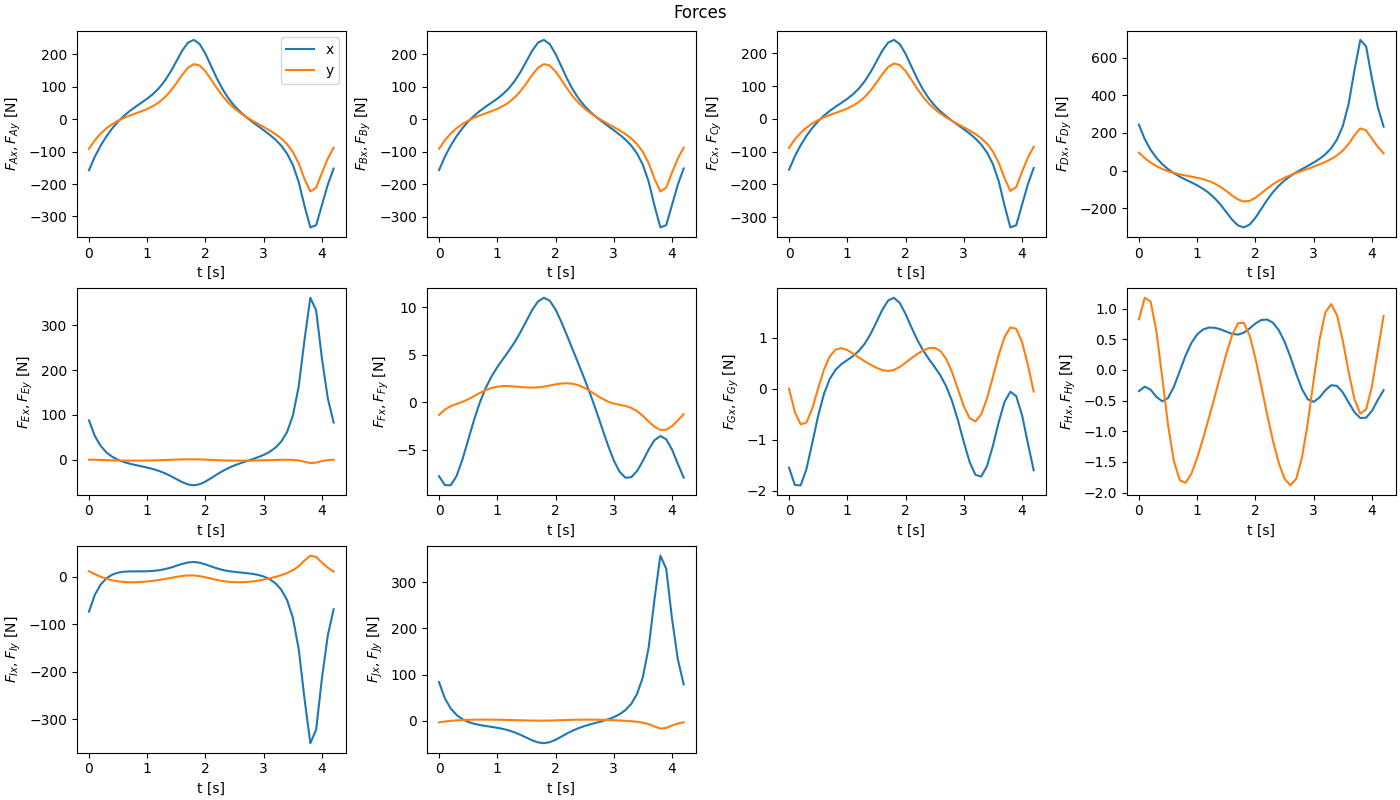

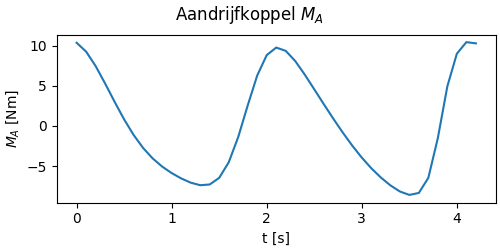

In [13]:
# plot forces and moments:
fig4, ax4 = plt.subplots(nrows=3, ncols=4, constrained_layout=True, figsize=(14, 8))
fig4.suptitle("Forces")

joints = [('A', F_A_x, F_A_y), ('B', F_B_x, F_B_y), ('C', F_C_x, F_C_y),
          ('D', F_D_x, F_D_y), ('E', F_E_x, F_E_y), ('F', F_F_x, F_F_y),
          ('G', F_G_x, F_G_y), ('H', F_H_x, F_H_y), ('I', F_I_x, F_I_y),
          ('J', F_J_x, F_J_y)]

for idx, (name, Fx, Fy) in enumerate(joints):
    row, col = divmod(idx, 4)
    ax4[row, col].plot(t, Fx, label="x")
    ax4[row, col].plot(t, Fy, label="y")
    ax4[row, col].set_ylabel(rf'$F_{{{name}x}}, F_{{{name}y}}$ [N]')
    ax4[row, col].set_xlabel('t [s]')
    if idx == 0:
        ax4[row, col].legend()

# verberg de ongebruikte assen:
for idx in range(len(joints), 12):
    row, col = divmod(idx, 4)
    ax4[row, col].axis('off')

plt.show()

fig5, ax5 = plt.subplots(constrained_layout=True, figsize=(5, 2.5))
fig5.suptitle("Aandrijfkoppel $M_A$")

ax5.plot(t, M_A)
ax5.set_ylabel(r'$M_A$ [Nm]')
ax5.set_xlabel('t [s]')

plt.show()
